In [26]:
import numpy as np
import matplotlib.pyplot as plt
import time
import torch
import networkx as nx
from torch_geometric.utils import to_networkx
from torch_geometric.datasets import KarateClub

## load data

In [27]:
dataset = KarateClub()

In [28]:
print("Number of graphs: ", len(dataset))
print("Number of features: ", dataset.num_features)
print("Number of classes: ",dataset.num_classes)
print("Number of node features: ",dataset.num_node_features) ## each node has how many feature?
print("Number of edge features: ",dataset.num_edge_features)

Number of graphs:  1
Number of features:  34
Number of classes:  4
Number of node features:  34
Number of edge features:  0


In [29]:
data = dataset[0] #  first graph 
print(data)

Data(x=[34, 34], edge_index=[2, 156], y=[34], train_mask=[34])


## Undirected vs directed graph

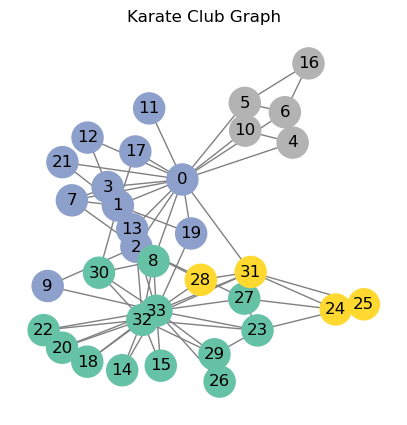

In [30]:
# Convert to networkx
G = to_networkx(data, to_undirected=True) ## undirected 

# Node colors from labels
node_color = data.y.numpy()

# Draw
plt.figure(figsize=(5, 5))
pos = nx.spring_layout(G, seed=42)

nx.draw_networkx(
    G,
    pos=pos,
    node_color=node_color,
    cmap=plt.cm.Set2,
    with_labels=True,
    node_size=500,
    edge_color="gray"
)

plt.title("Karate Club Graph")
plt.axis("off")
plt.show()

In [31]:
karate_undirected_graph = to_networkx(data, to_undirected=True)
print(karate_undirected_graph.nodes)
print(karate_undirected_graph.number_of_edges())
print(karate_undirected_graph.edges)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]
78
[(0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (0, 8), (0, 10), (0, 11), (0, 12), (0, 13), (0, 17), (0, 19), (0, 21), (0, 31), (1, 2), (1, 3), (1, 7), (1, 13), (1, 17), (1, 19), (1, 21), (1, 30), (2, 3), (2, 7), (2, 8), (2, 9), (2, 13), (2, 27), (2, 28), (2, 32), (3, 7), (3, 12), (3, 13), (4, 6), (4, 10), (5, 6), (5, 10), (5, 16), (6, 16), (8, 30), (8, 32), (8, 33), (9, 33), (13, 33), (14, 32), (14, 33), (15, 32), (15, 33), (18, 32), (18, 33), (19, 33), (20, 32), (20, 33), (22, 32), (22, 33), (23, 25), (23, 27), (23, 29), (23, 32), (23, 33), (24, 25), (24, 27), (24, 31), (25, 31), (26, 29), (26, 33), (27, 33), (28, 31), (28, 33), (29, 32), (29, 33), (30, 32), (30, 33), (31, 32), (31, 33), (32, 33)]


### directed graph

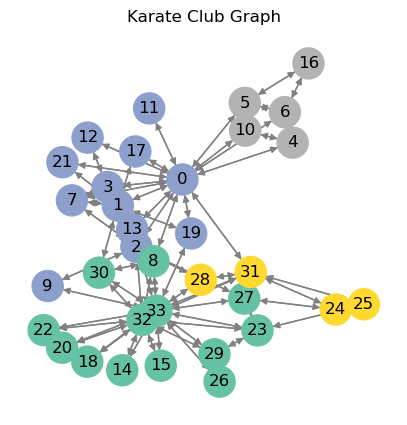

In [32]:
# Convert to networkx
G = to_networkx(data, to_undirected=False) ## directed 

# Node colors from labels
node_color = data.y.numpy()

# Draw
plt.figure(figsize=(5, 5))
pos = nx.spring_layout(G, seed=42)

nx.draw_networkx(
    G,
    pos=pos,
    node_color=node_color,
    cmap=plt.cm.Set2,
    with_labels=True,
    node_size=500,
    edge_color="gray"
)

plt.title("Karate Club Graph")
plt.axis("off")
plt.show()

In [33]:
karate_directed_graph = to_networkx(data, to_undirected=False)
print(karate_directed_graph.nodes)
print(karate_directed_graph.number_of_edges())
print(karate_directed_graph.edges)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]
156
[(0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (0, 8), (0, 10), (0, 11), (0, 12), (0, 13), (0, 17), (0, 19), (0, 21), (0, 31), (1, 0), (1, 2), (1, 3), (1, 7), (1, 13), (1, 17), (1, 19), (1, 21), (1, 30), (2, 0), (2, 1), (2, 3), (2, 7), (2, 8), (2, 9), (2, 13), (2, 27), (2, 28), (2, 32), (3, 0), (3, 1), (3, 2), (3, 7), (3, 12), (3, 13), (4, 0), (4, 6), (4, 10), (5, 0), (5, 6), (5, 10), (5, 16), (6, 0), (6, 4), (6, 5), (6, 16), (7, 0), (7, 1), (7, 2), (7, 3), (8, 0), (8, 2), (8, 30), (8, 32), (8, 33), (9, 2), (9, 33), (10, 0), (10, 4), (10, 5), (11, 0), (12, 0), (12, 3), (13, 0), (13, 1), (13, 2), (13, 3), (13, 33), (14, 32), (14, 33), (15, 32), (15, 33), (16, 5), (16, 6), (17, 0), (17, 1), (18, 32), (18, 33), (19, 0), (19, 1), (19, 33), (20, 32), (20, 33), (21, 0), (21, 1), (22, 32), (22, 33), (23, 25), (23, 27), (23, 29), (23, 32), (23, 33), (24, 

#### Directed and Undirected Graph handling in PyG

PyG does not distinguish between directed and undirected graphs, and treats undirected graphs as a special case of directed graphs in which reverse edges exist for every entry in ``edge_index``

## Data exploration

In [34]:
data.stores

[{'x': tensor([[1., 0., 0.,  ..., 0., 0., 0.],
         [0., 1., 0.,  ..., 0., 0., 0.],
         [0., 0., 1.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 1., 0., 0.],
         [0., 0., 0.,  ..., 0., 1., 0.],
         [0., 0., 0.,  ..., 0., 0., 1.]]), 'edge_index': tensor([[ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1,
           1,  1,  1,  1,  1,  1,  1,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  3,
           3,  3,  3,  3,  3,  4,  4,  4,  5,  5,  5,  5,  6,  6,  6,  6,  7,  7,
           7,  7,  8,  8,  8,  8,  8,  9,  9, 10, 10, 10, 11, 12, 12, 13, 13, 13,
          13, 13, 14, 14, 15, 15, 16, 16, 17, 17, 18, 18, 19, 19, 19, 20, 20, 21,
          21, 22, 22, 23, 23, 23, 23, 23, 24, 24, 24, 25, 25, 25, 26, 26, 27, 27,
          27, 27, 28, 28, 28, 29, 29, 29, 29, 30, 30, 30, 30, 31, 31, 31, 31, 31,
          31, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 33, 33, 33, 33, 33,
          33, 33, 33, 33, 33, 33, 33, 33, 33, 33, 33, 33],
    

In [35]:
### targes
data.y

tensor([1, 1, 1, 1, 3, 3, 3, 1, 0, 1, 3, 1, 1, 1, 0, 0, 3, 1, 0, 1, 0, 1, 0, 0,
        2, 2, 0, 0, 2, 0, 0, 2, 0, 0])

In [36]:
print(data.train_mask)
print("number of data for traning:",data.train_mask.sum())

tensor([ True, False, False, False,  True, False, False, False,  True, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False,  True, False, False, False, False, False,
        False, False, False, False])
number of data for traning: tensor(4)


Above only 4 nodes have mask value set as True, it means only 4 out of 34 nodes have community or class assignment, rest of the 30 nodes needs community assignment.

Train Mask -> In total, we are only aware of the ground-truth labels of 4 nodes (one for each community), and the task is to infer the community assignment for the remaining nodes.

NOTE:
 
If the graph holds the additional attributes i.e. val_mask and test_mask, which denotes which nodes should be used for validation and testing.

### Model Build

In [37]:
import torch
from torch.nn import Linear
from torch_geometric.nn import GCNConv

In [38]:
class GCN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        torch.manual_seed(123)

        self.conv1 = GCNConv(dataset.num_features, 4) 
        self.conv2 = GCNConv(4, 4) 
        self.conv3 = GCNConv(4, 2) 
        self.classifier = Linear(2, dataset.num_classes)

    def forward(self, x, edge_index):
        h = self.conv1(x, edge_index)
        h = h.tanh()
        h = self.conv2(h, edge_index)
        h = h.tanh()
        h = self.conv3(h, edge_index)
        h = h.tanh() # Final GNN embedding space

        # Apply a final (linear) classifier.
        out = self.classifier(h)

        return out, h

model = GCN()
print(model)

GCN(
  (conv1): GCNConv(34, 4)
  (conv2): GCNConv(4, 4)
  (conv3): GCNConv(4, 2)
  (classifier): Linear(in_features=2, out_features=4, bias=True)
)


In [39]:
_, h = model(data.x, data.edge_index)
print(f'Embedding shape: {list(h.shape)}')

Embedding shape: [34, 2]


In [40]:
h

tensor([[ 1.7256e-01,  5.3418e-03],
        [ 1.6819e-01,  8.7419e-03],
        [ 1.7577e-01,  8.2662e-03],
        [ 1.0140e-01,  7.5317e-03],
        [ 3.0203e-02, -6.7940e-03],
        [ 3.7959e-02, -8.9290e-03],
        [ 3.8908e-02, -9.4607e-03],
        [ 1.0586e-01,  5.6527e-03],
        [ 1.0995e-01,  1.1134e-03],
        [ 8.1859e-02,  5.9171e-03],
        [ 2.3559e-02, -7.5275e-03],
        [ 7.6762e-02,  7.0648e-03],
        [ 3.7978e-02,  5.0403e-03],
        [ 1.1141e-01,  5.0575e-03],
        [ 6.4049e-02, -2.1072e-03],
        [ 5.8679e-02, -3.1270e-03],
        [ 2.5680e-02, -9.6004e-03],
        [ 1.0831e-01,  5.8673e-03],
        [ 7.6697e-02, -1.4917e-03],
        [ 1.0528e-01,  1.4232e-03],
        [ 5.9742e-02, -4.1160e-03],
        [ 1.0386e-01,  4.8557e-03],
        [ 5.7057e-02,  9.9430e-04],
        [ 2.0106e-01, -6.9323e-04],
        [ 2.4004e-01, -3.5643e-03],
        [ 2.3440e-01, -1.9430e-03],
        [ 9.4429e-02,  5.9583e-03],
        [ 1.9029e-01, -4.408

### Embedding Visualization

In [41]:
def visualize_embedding(h, color, epoch=None, loss=None):
    plt.figure(figsize=(6,6))
    plt.xticks([])
    plt.yticks([])
    h = h.detach().cpu().numpy()
    plt.scatter(h[:, 0], h[:, 1], s=140, c=color, cmap="Set2")
    if epoch is not None and loss is not None:
        plt.xlabel(f'Epoch: {epoch}, Loss: {loss.item():.4f}', fontsize=16)
    plt.show()

In [42]:
from sklearn.manifold import TSNE

def visualize_tsne(h, color):
    z = TSNE(n_components=2).fit_transform(h.detach().cpu().numpy())

    plt.figure(figsize=(6,6))
    plt.xticks([])
    plt.yticks([])

    plt.scatter(z[:, 0], z[:, 1], s=70, c=color, cmap="Set2")
    plt.show()

In [43]:
data.y

tensor([1, 1, 1, 1, 3, 3, 3, 1, 0, 1, 3, 1, 1, 1, 0, 0, 3, 1, 0, 1, 0, 1, 0, 0,
        2, 2, 0, 0, 2, 0, 0, 2, 0, 0])

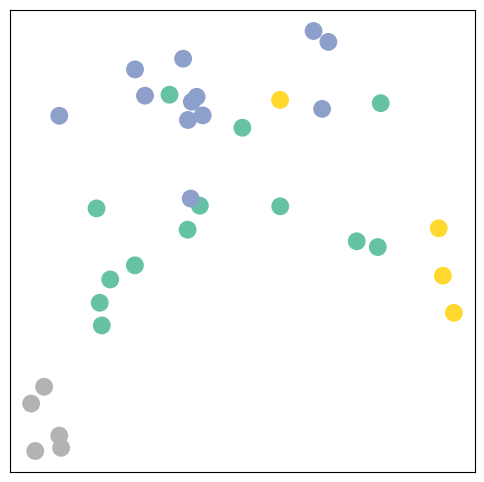

In [44]:
visualize_embedding(h, color=data.y)

### Model Train

In [45]:
model = GCN()
criterion = torch.nn.CrossEntropyLoss()  ### define loss criterion
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)  ### dfine optimizer

In [46]:
final_h = h

In [47]:
def train(data):
    optimizer.zero_grad()  # Clear gradients.
    out, h = model(data.x, data.edge_index)  # Perform a single forward pass.
    loss = criterion(out[data.train_mask], data.y[data.train_mask])  # Compute the loss solely based on the training nodes.
    loss.backward()  # Derive gradients.
    optimizer.step()  # Update parameters based on gradients.
    return loss, h

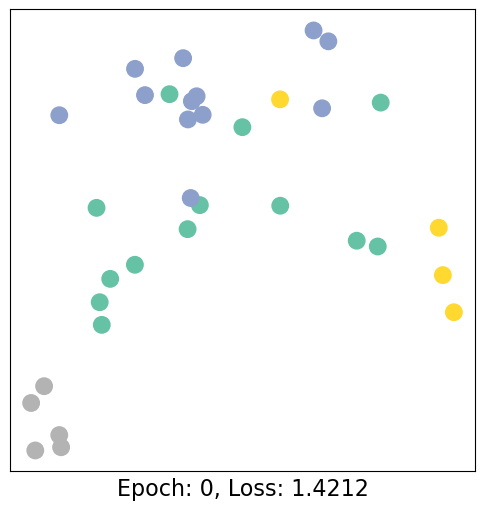

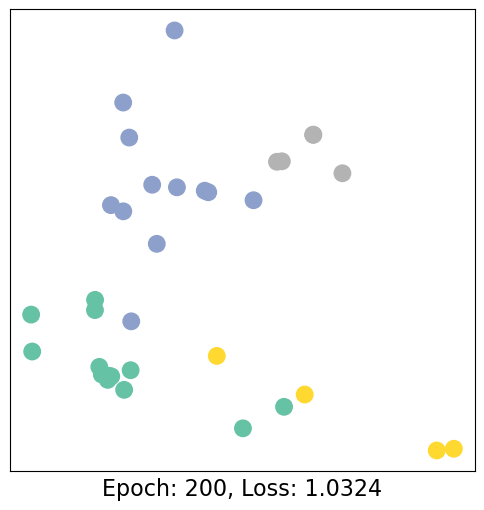

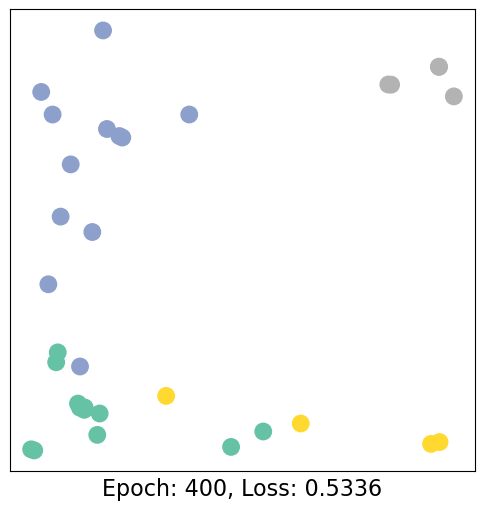

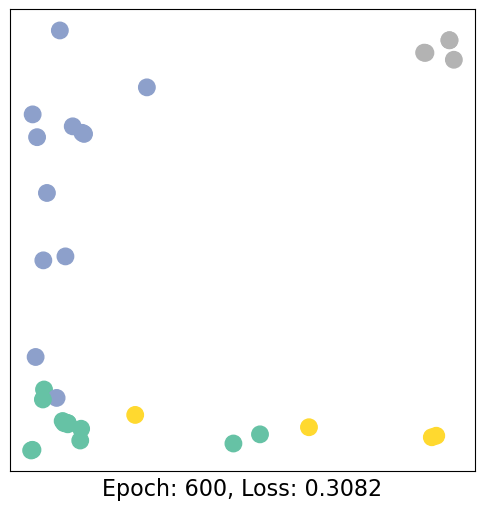

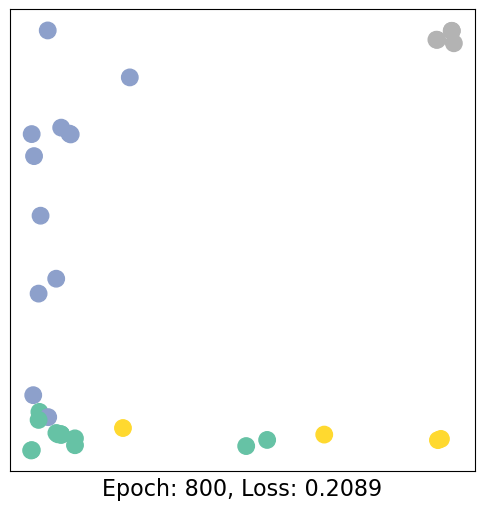

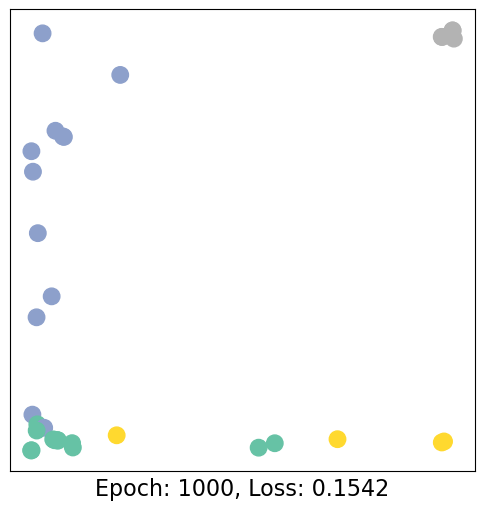

In [48]:
for epoch in range(1200):
    loss, h = train(data)
    if epoch % 200 == 0:
        visualize_embedding(h, color=data.y, epoch=epoch, loss=loss)
        time.sleep(0.3)
        ## Added for final visualization
        final_h = h

### TSNE Visulalization

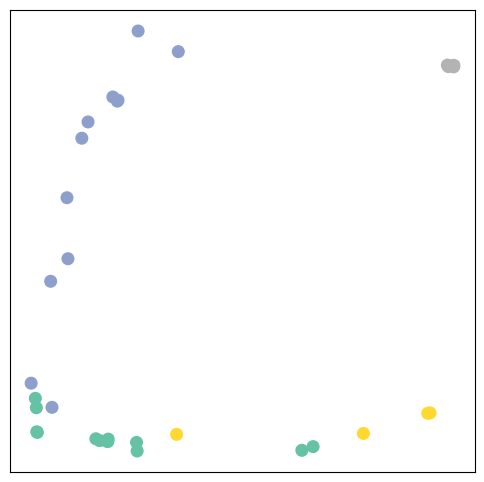

In [49]:
visualize_tsne(h, color=data.y)

### Model eval

In [50]:
model.eval()
out = model(data.x, data.edge_index)
out

(tensor([[-0.4098,  2.3431, -3.2601, -0.1075],
         [ 0.6208,  1.4696, -2.3165, -1.0942],
         [ 2.5947, -0.3940, -0.2666, -2.9746],
         [ 0.7560,  1.3299, -2.1607, -1.2223],
         [-3.2213,  0.4214, -0.3514,  2.7995],
         [-3.3136,  0.4184, -0.3325,  2.8920],
         [-3.3135,  0.4183, -0.3324,  2.8919],
         [ 1.2035,  0.8653, -1.6423, -1.6465],
         [ 2.6136, -0.4581, -0.1880, -2.9903],
         [ 2.5924, -0.5027, -0.1277, -2.9668],
         [-3.2189,  0.4240, -0.3551,  2.7970],
         [-0.6343,  1.7219, -2.4320,  0.1480],
         [ 0.2417,  1.5939, -2.4126, -0.7214],
         [ 1.8771,  0.2422, -0.9592, -2.2889],
         [ 2.5692, -0.6361,  0.0460, -2.9370],
         [ 2.5894, -0.6220,  0.0247, -2.9579],
         [-3.2764,  0.3731, -0.2808,  2.8570],
         [ 0.2352,  1.5232, -2.3216, -0.7113],
         [ 2.5699, -0.6344,  0.0436, -2.9377],
         [ 1.5987,  0.3525, -1.0540, -2.0161],
         [ 2.5707, -0.6385,  0.0488, -2.9383],
         [ 0.